# Investment Research Agent v2

## 에이전트 설계

### 목적
종목 티커와 분석 유형을 입력받아 yfinance 주가 데이터, RSS 뉴스를 수집·분석하고
투자자 관점의 종합 보고서를 자동으로 생성한다.

### 분석 모드 (report_type)
- **`technical`**: 주가 데이터 수집 → 기술적 지표 계산 → 보고서
- **`news`**: 뉴스 쿼리 생성 → RSS 뉴스 수집 → 보고서
- **`full`**: 주가 데이터 + 기술적 지표 + 뉴스 쿼리 + RSS 뉴스 → 종합 보고서

### 그래프 구조

```
START
  │
  ▼
┌──────────────────┐
│  route_request   │  report_type 검증 및 라우팅
└────────┬─────────┘
         │
         ▼  [Conditional Edge 1: report_type]
         ├── "technical" or "full" ──► fetch_stock_data
         │                                   │
         │                                   ▼
         │                          calculate_indicators
         │                                   │
         │                                   ▼  [Conditional Edge 2: report_type]
         │                                   ├── "technical" ──────────────────┐
         │                                   └── "full" ──► generate_news_query │
         │                                                        │             │
         │                                                        ▼             │
         └── "news" ──► generate_news_query ──► fetch_news ──────►│             │
                                                                   ▼             │
                                                             generate_report ◄──┘
                                                                   │
                                                                   ▼
                                                                  END
```

### State 정의
```python
class InvestmentState(TypedDict):
    ticker: str          # 입력: 종목 티커 (e.g., "AAPL", "005930.KS")
    report_type: str     # 입력: "technical" | "news" | "full"
    stock_data: dict     # yfinance 원시 데이터
    indicators: dict     # 기술적 지표 (MA, RSI, MACD, BB)
    news_query: str      # LLM 생성 뉴스 검색 쿼리
    news_items: list     # RSS 뉴스 기사
    report: str          # 최종 보고서
```

### Tools
- `get_stock_data(ticker)` — yfinance 6개월 주가 + 종목 info
- `get_rss_news(query)` — Google News RSS 최신 기사 10개

In [1]:
# ── 패키지 임포트 ──────────────────────────────────────────────────────────────
import os
import urllib.request
import urllib.parse
import xml.etree.ElementTree as ET
from typing import TypedDict, Literal

import yfinance as yf
import pandas as pd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END

load_dotenv()
print("패키지 로드 완료")

패키지 로드 완료


In [2]:
# ── State 정의 ────────────────────────────────────────────────────────────────
class InvestmentState(TypedDict):
    ticker: str          # 입력: 종목 티커 (e.g., "AAPL", "005930.KS")
    report_type: str     # 입력: "technical" | "news" | "full"
    stock_data: dict     # yfinance 원시 데이터
    indicators: dict     # 기술적 지표 (MA, RSI, MACD, BB)
    news_query: str      # LLM 생성 뉴스 검색 쿼리
    news_items: list     # RSS 뉴스 기사
    report: str          # 최종 보고서

print("InvestmentState 정의 완료:", list(InvestmentState.__annotations__.keys()))

InvestmentState 정의 완료: ['ticker', 'report_type', 'stock_data', 'indicators', 'news_query', 'news_items', 'report']


In [3]:
# ── LLM 초기화 ────────────────────────────────────────────────────────────────
llm = ChatOpenAI(model="gpt-4o", temperature=0)
print("LLM 초기화 완료:", llm.model)

LLM 초기화 완료: gpt-4o


In [ ]:
# ── Tools 정의 (@tool 데코레이터) ─────────────────────────────────────────────

@tool
def get_stock_data(ticker: str) -> dict:
    """yfinance를 사용해 종목의 6개월 주가 데이터와 기본 정보를 가져온다."""
    t = yf.Ticker(ticker)
    hist = t.history(period="6mo")
    info = t.info

    hist_reset = hist.reset_index()
    # .date() 로 timezone-naive 날짜만 추출 → 혼합 타임존 문제 완전 우회
    hist_reset["Date"] = hist_reset["Date"].apply(lambda x: x.date().isoformat())
    records = hist_reset[["Date", "Open", "High", "Low", "Close", "Volume"]].to_dict(orient="records")

    return {
        "history": records,
        "info": {
            "longName": info.get("longName", ticker),
            "sector": info.get("sector", "N/A"),
            "industry": info.get("industry", "N/A"),
            "marketCap": info.get("marketCap"),
            "trailingPE": info.get("trailingPE"),
            "dividendYield": info.get("dividendYield"),
            "fiftyTwoWeekHigh": info.get("fiftyTwoWeekHigh"),
            "fiftyTwoWeekLow": info.get("fiftyTwoWeekLow"),
            "currency": info.get("currency", "USD"),
        },
    }


@tool
def get_rss_news(query: str) -> list:
    """Google News RSS에서 주어진 쿼리로 최신 뉴스 기사를 최대 10개 가져온다."""
    encoded = urllib.parse.quote(query)
    url = f"https://news.google.com/rss/search?q={encoded}&hl=en-US&gl=US&ceid=US:en"
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=10) as resp:
            content = resp.read()
        root = ET.fromstring(content)
        items = root.findall(".//item")[:10]
        return [
            {
                "title": item.findtext("title", "").strip(),
                "pubDate": item.findtext("pubDate", "")[:16],
                "link": item.findtext("link", ""),
                "source": item.findtext("source", ""),
            }
            for item in items
        ]
    except Exception as e:
        return [{"title": f"뉴스 가져오기 실패: {e}", "pubDate": "", "link": "", "source": ""}]


print("Tools 정의 완료: get_stock_data / get_rss_news")

In [5]:
# ── Node: route_request ───────────────────────────────────────────────────────
def route_request(state: InvestmentState) -> InvestmentState:
    """입력값을 검증하고 분석 유형을 확정한다."""
    report_type = state.get("report_type", "full")
    if report_type not in ("technical", "news", "full"):
        report_type = "full"
    ticker = state["ticker"].upper()
    print(f"[route_request] 티커: {ticker} | 분석 유형: {report_type}")
    return {**state, "ticker": ticker, "report_type": report_type}


# ── Conditional Edge 1: report_type → 첫 번째 분기 ───────────────────────────
def route_after_request(state: InvestmentState) -> str:
    """report_type에 따라 첫 번째 분기를 결정한다."""
    rt = state["report_type"]
    dest = "fetch_stock_data" if rt in ("technical", "full") else "generate_news_query"
    print(f"  → Conditional Edge 1: '{rt}' → {dest}")
    return dest


print("route_request 노드 및 Conditional Edge 1 정의 완료")

route_request 노드 및 Conditional Edge 1 정의 완료


In [ ]:
# ── Node: fetch_stock_data ────────────────────────────────────────────────────
def fetch_stock_data(state: InvestmentState) -> InvestmentState:
    """get_stock_data Tool로 yfinance 주가 데이터를 수집한다."""
    ticker = state["ticker"]
    print(f"[fetch_stock_data] {ticker} 주가 데이터 수집 중...")

    data = get_stock_data.invoke({"ticker": ticker})
    info = data["info"]
    print(f"  → {info['longName']} | 섹터: {info['sector']} | {len(data['history'])}일 데이터")
    print(f"  → 시가총액: {info.get('marketCap', 'N/A')} | PER: {info.get('trailingPE', 'N/A')}")
    return {**state, "stock_data": data}


# ── Node: calculate_indicators ────────────────────────────────────────────────
def calculate_indicators(state: InvestmentState) -> InvestmentState:
    """pandas로 MA, RSI, MACD, Bollinger Bands를 계산한다."""
    print("[calculate_indicators] 기술적 지표 계산 중...")

    df = pd.DataFrame(state["stock_data"]["history"])
    # get_stock_data 툴이 이미 "YYYY-MM-DD" 문자열로 정규화했으므로 단순 변환
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    close = df["Close"].astype(float)

    # 이동평균
    df["MA20"] = close.rolling(20).mean()
    df["MA60"] = close.rolling(60).mean()

    # RSI(14)
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df["RSI14"] = 100 - (100 / (1 + gain / loss))

    # MACD (12, 26, 9)
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df["MACD"] = ema12 - ema26
    df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACD_hist"] = df["MACD"] - df["MACD_signal"]

    # Bollinger Bands (20, 2σ)
    df["BB_mid"] = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    df["BB_upper"] = df["BB_mid"] + 2 * bb_std
    df["BB_lower"] = df["BB_mid"] - 2 * bb_std

    latest = df.iloc[-1]
    prev = df.iloc[-2]

    rsi_val = float(latest["RSI14"])
    rsi_signal = (
        "과매수 (Overbought ≥70)" if rsi_val >= 70
        else "과매도 (Oversold ≤30)" if rsi_val <= 30
        else "중립 (Neutral)"
    )
    macd_signal = "강세" if float(latest["MACD_hist"]) > 0 else "약세"
    ma_trend = (
        "MA20 > MA60 → 상승추세" if float(latest["MA20"]) > float(latest["MA60"])
        else "MA20 < MA60 → 하락추세"
    )
    bb_range = float(latest["BB_upper"]) - float(latest["BB_lower"])
    bb_pos = round((float(latest["Close"]) - float(latest["BB_lower"])) / bb_range * 100, 1) if bb_range else 50.0

    indicators = {
        "current_price": round(float(latest["Close"]), 2),
        "price_change_pct": round((float(latest["Close"]) / float(prev["Close"]) - 1) * 100, 2),
        "MA20": round(float(latest["MA20"]), 2),
        "MA60": round(float(latest["MA60"]), 2),
        "RSI14": round(rsi_val, 2),
        "MACD_hist": round(float(latest["MACD_hist"]), 4),
        "BB_upper": round(float(latest["BB_upper"]), 2),
        "BB_mid": round(float(latest["BB_mid"]), 2),
        "BB_lower": round(float(latest["BB_lower"]), 2),
        "BB_position_pct": bb_pos,
        "rsi_signal": rsi_signal,
        "macd_signal": macd_signal,
        "ma_trend": ma_trend,
        "recent_5days": (
            df.tail(5)[["Date", "Close", "Volume", "MA20", "RSI14"]]
            .assign(Date=lambda x: x["Date"].astype(str))
            .round(2)
            .to_dict(orient="records")
        ),
    }

    print(f"  → 현재가: {indicators['current_price']} ({indicators['price_change_pct']:+.2f}%)")
    print(f"  → RSI: {indicators['RSI14']} | {rsi_signal}")
    print(f"  → MACD: {macd_signal} | {ma_trend}")
    return {**state, "indicators": indicators}


# ── Conditional Edge 2: report_type 확인 후 두 번째 분기 ──────────────────────
def route_after_indicators(state: InvestmentState) -> str:
    """기술적 지표 계산 후 full이면 뉴스 수집, technical이면 바로 보고서 생성."""
    rt = state["report_type"]
    dest = "generate_news_query" if rt == "full" else "generate_report"
    print(f"  → Conditional Edge 2: '{rt}' → {dest}")
    return dest


print("fetch_stock_data / calculate_indicators 노드 및 Conditional Edge 2 정의 완료")

In [7]:
# ── Node: generate_news_query ─────────────────────────────────────────────────
def generate_news_query(state: InvestmentState) -> InvestmentState:
    """LLM이 종목 특성과 기술적 지표를 바탕으로 최적 뉴스 검색 쿼리를 생성한다."""
    print("[generate_news_query] 뉴스 검색 쿼리 생성 중...")

    ticker = state["ticker"]
    indicators = state.get("indicators", {})
    stock_info = state.get("stock_data", {}).get("info", {})

    # 기술적 지표가 있으면 함께 활용, 없으면 종목명만으로 쿼리 생성
    tech_context = ""
    if indicators:
        tech_context = (
            f"현재가: {indicators.get('current_price', 'N/A')} "
            f"({indicators.get('price_change_pct', 0):+.2f}%)\n"
            f"RSI: {indicators.get('RSI14', 'N/A')} → {indicators.get('rsi_signal', '')}\n"
            f"MACD: {indicators.get('macd_signal', '')} | {indicators.get('ma_trend', '')}\n"
        )

    messages = [
        SystemMessage(content=(
            "당신은 금융 뉴스 검색 전문가입니다. "
            "주어진 종목 정보를 바탕으로 투자자에게 가장 유용한 "
            "최신 뉴스를 찾을 Google News 검색 쿼리를 1개 생성하세요.\n\n"
            "규칙:\n"
            "- 영어로 작성\n"
            "- 회사명 + 투자 관련 키워드 (earnings, outlook, analyst, forecast 등)\n"
            "- 기술적 시그널이 특이할 경우 관련 키워드 포함\n"
            "- 쿼리 문자열만 출력 (따옴표·설명 없이)"
        )),
        HumanMessage(content=(
            f"종목: {ticker}\n"
            f"회사명: {stock_info.get('longName', ticker)}\n"
            f"섹터: {stock_info.get('sector', 'N/A')} / {stock_info.get('industry', 'N/A')}\n"
            f"{tech_context}\n"
            "최적의 Google News 검색 쿼리를 생성하세요."
        )),
    ]

    response = llm.invoke(messages)
    query = response.content.strip().strip('"').strip("'")
    print(f"  → 생성된 쿼리: '{query}'")
    return {**state, "news_query": query}


# ── Node: fetch_news ──────────────────────────────────────────────────────────
def fetch_news(state: InvestmentState) -> InvestmentState:
    """get_rss_news Tool로 최신 뉴스를 가져온다."""
    query = state["news_query"]
    print(f"[fetch_news] RSS 뉴스 수집: '{query}'")

    news = get_rss_news.invoke({"query": query})
    print(f"  → {len(news)}개 기사 수집")
    for item in news[:3]:
        print(f"    - {item['title'][:72]}")
    return {**state, "news_items": news}


print("generate_news_query / fetch_news 노드 정의 완료")

generate_news_query / fetch_news 노드 정의 완료


In [8]:
# ── Node: generate_report ─────────────────────────────────────────────────────
def generate_report(state: InvestmentState) -> InvestmentState:
    """수집된 데이터를 종합해 LLM으로 투자 분석 보고서를 생성한다."""
    print("[generate_report] 최종 보고서 생성 중...")

    ticker = state["ticker"]
    report_type = state["report_type"]
    indicators = state.get("indicators", {})
    stock_info = state.get("stock_data", {}).get("info", {})
    news = state.get("news_items", [])
    currency = stock_info.get("currency", "USD")

    # 기술적 지표 섹션
    tech_section = ""
    if indicators:
        tech_section = (
            f"\n\n## 기술적 지표\n"
            f"| 지표 | 값 | 시그널 |\n"
            f"|------|-----|--------|\n"
            f"| 현재가 | {indicators['current_price']} {currency} | 전일 대비 {indicators['price_change_pct']:+.2f}% |\n"
            f"| MA20 | {indicators['MA20']} | {indicators['ma_trend']} |\n"
            f"| MA60 | {indicators['MA60']} | |\n"
            f"| RSI(14) | {indicators['RSI14']} | {indicators['rsi_signal']} |\n"
            f"| MACD Hist | {indicators['MACD_hist']} | {indicators['macd_signal']} |\n"
            f"| BB 상단/하단 | {indicators['BB_upper']} / {indicators['BB_lower']} | 현재 위치: {indicators['BB_position_pct']}% |\n"
            f"| 52주 고/저 | {stock_info.get('fiftyTwoWeekHigh','N/A')} / {stock_info.get('fiftyTwoWeekLow','N/A')} | |"
        )

    # 뉴스 섹션
    news_section = ""
    if news:
        news_section = f"\n\n## 최근 뉴스 (검색 쿼리: `{state.get('news_query', '')}`)"
        for n in news:
            news_section += f"\n- **{n['title']}** ({n['pubDate']}) — {n.get('source', '')}"

    # 보고서 구조 결정
    report_sections = {
        "technical": "## 1. 종목 개요\n## 2. 기술적 지표 분석 (표 포함)\n## 3. 차트 시그널 해석\n## 4. 종합 투자 의견",
        "news": "## 1. 종목 개요\n## 2. 최근 뉴스 동향 분석\n## 3. 뉴스가 시사하는 투자 포인트\n## 4. 종합 투자 의견",
        "full": "## 1. 종목 개요\n## 2. 기술적 지표 분석 (표 포함)\n## 3. 최근 뉴스 동향\n## 4. 종합 해석 (기술적 + 뉴스 통합)\n## 5. 종합 투자 의견 (매수/중립/매도)",
    }

    messages = [
        SystemMessage(content=(
            "당신은 기관 투자자를 위한 시니어 주식 애널리스트입니다. "
            "주어진 데이터를 바탕으로 투자 분석 보고서를 한국어로 작성하세요.\n\n"
            f"보고서 구조:\n# [종목명] 투자 분석 보고서\n\n{report_sections.get(report_type, report_sections['full'])}\n\n"
            "---\n*본 보고서는 AI 생성 참고 자료이며 투자 권유가 아닙니다.*"
        )),
        HumanMessage(content=(
            f"종목: {ticker} — {stock_info.get('longName', ticker)}\n"
            f"섹터: {stock_info.get('sector', 'N/A')} / {stock_info.get('industry', 'N/A')}\n"
            f"PER: {stock_info.get('trailingPE', 'N/A')} | 배당수익률: {stock_info.get('dividendYield', 'N/A')}"
            f"{tech_section}"
            f"{news_section}"
        )),
    ]

    response = llm.invoke(messages)
    report = response.content
    print(f"  → 보고서 생성 완료 ({len(report):,}자)")
    return {**state, "report": report}


print("generate_report 노드 정의 완료")

generate_report 노드 정의 완료


In [9]:
# ── 그래프 빌드 ────────────────────────────────────────────────────────────────
builder = StateGraph(InvestmentState)

# 노드 등록
builder.add_node("route_request", route_request)
builder.add_node("fetch_stock_data", fetch_stock_data)
builder.add_node("calculate_indicators", calculate_indicators)
builder.add_node("generate_news_query", generate_news_query)
builder.add_node("fetch_news", fetch_news)
builder.add_node("generate_report", generate_report)

# 기본 엣지
builder.add_edge(START, "route_request")

# ── Conditional Edge 1: route_request → fetch_stock_data or generate_news_query
builder.add_conditional_edges(
    "route_request",
    route_after_request,
    {
        "fetch_stock_data": "fetch_stock_data",
        "generate_news_query": "generate_news_query",
    },
)

# 주가 분석 경로
builder.add_edge("fetch_stock_data", "calculate_indicators")

# ── Conditional Edge 2: calculate_indicators → generate_news_query or generate_report
builder.add_conditional_edges(
    "calculate_indicators",
    route_after_indicators,
    {
        "generate_news_query": "generate_news_query",
        "generate_report": "generate_report",
    },
)

# 뉴스 경로
builder.add_edge("generate_news_query", "fetch_news")
builder.add_edge("fetch_news", "generate_report")
builder.add_edge("generate_report", END)

# 컴파일
graph = builder.compile()

print("그래프 컴파일 완료")
print("Conditional Edge 1: route_request → technical/full → fetch_stock_data | news → generate_news_query")
print("Conditional Edge 2: calculate_indicators → full → generate_news_query | technical → generate_report")

그래프 컴파일 완료
Conditional Edge 1: route_request → technical/full → fetch_stock_data | news → generate_news_query
Conditional Edge 2: calculate_indicators → full → generate_news_query | technical → generate_report


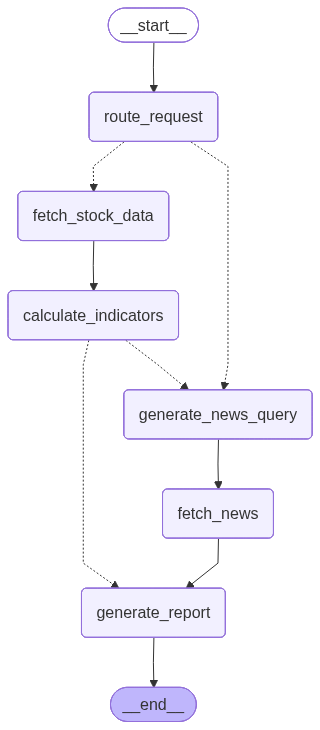

In [10]:
# ── 그래프 시각화 ─────────────────────────────────────────────────────────────
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("그래프 시각화 생략")

## 실행

In [11]:
# ── 실행 1: technical 모드 (주가 지표만) ────────────────────────────────────────
result_technical = graph.invoke({
    "ticker": "AAPL",
    "report_type": "technical",
    "stock_data": {},
    "indicators": {},
    "news_query": "",
    "news_items": [],
    "report": "",
})
print("\n실행 경로: route_request → fetch_stock_data → calculate_indicators → generate_report")

[route_request] 티커: AAPL | 분석 유형: technical
  → Conditional Edge 1: 'technical' → fetch_stock_data
[fetch_stock_data] AAPL 주가 데이터 수집 중...
  → Apple Inc. | 섹터: Technology | 124일 데이터
  → 시가총액: 3712989790208 | PER: 31.936789
[calculate_indicators] 기술적 지표 계산 중...


ValueError: Mixed timezones detected. Pass utc=True in to_datetime or tz='UTC' in DatetimeIndex to convert to a common timezone.

In [ ]:
from IPython.display import Markdown, display
display(Markdown(result_technical["report"]))

In [ ]:
# ── 실행 2: news 모드 (뉴스만) ──────────────────────────────────────────────────
result_news = graph.invoke({
    "ticker": "AAPL",
    "report_type": "news",
    "stock_data": {},
    "indicators": {},
    "news_query": "",
    "news_items": [],
    "report": "",
})
print(f"\n실행 경로: route_request → generate_news_query → fetch_news → generate_report")
print(f"검색 쿼리: {result_news['news_query']}")
print(f"수집된 뉴스: {len(result_news['news_items'])}개")

In [ ]:
display(Markdown(result_news["report"]))

In [ ]:
# ── 실행 3: full 모드 (주가 지표 + 뉴스 통합) ───────────────────────────────────
result_full = graph.invoke({
    "ticker": "AAPL",
    "report_type": "full",
    "stock_data": {},
    "indicators": {},
    "news_query": "",
    "news_items": [],
    "report": "",
})
print(f"\n실행 경로: route_request → fetch_stock_data → calculate_indicators → generate_news_query → fetch_news → generate_report")
print(f"검색 쿼리: {result_full['news_query']}")
print(f"수집된 뉴스: {len(result_full['news_items'])}개")

In [ ]:
display(Markdown(result_full["report"]))